> detector.detectAndDecode()



Decoded (full image): ''
Decoded (cropped/warped): 'IV26168'


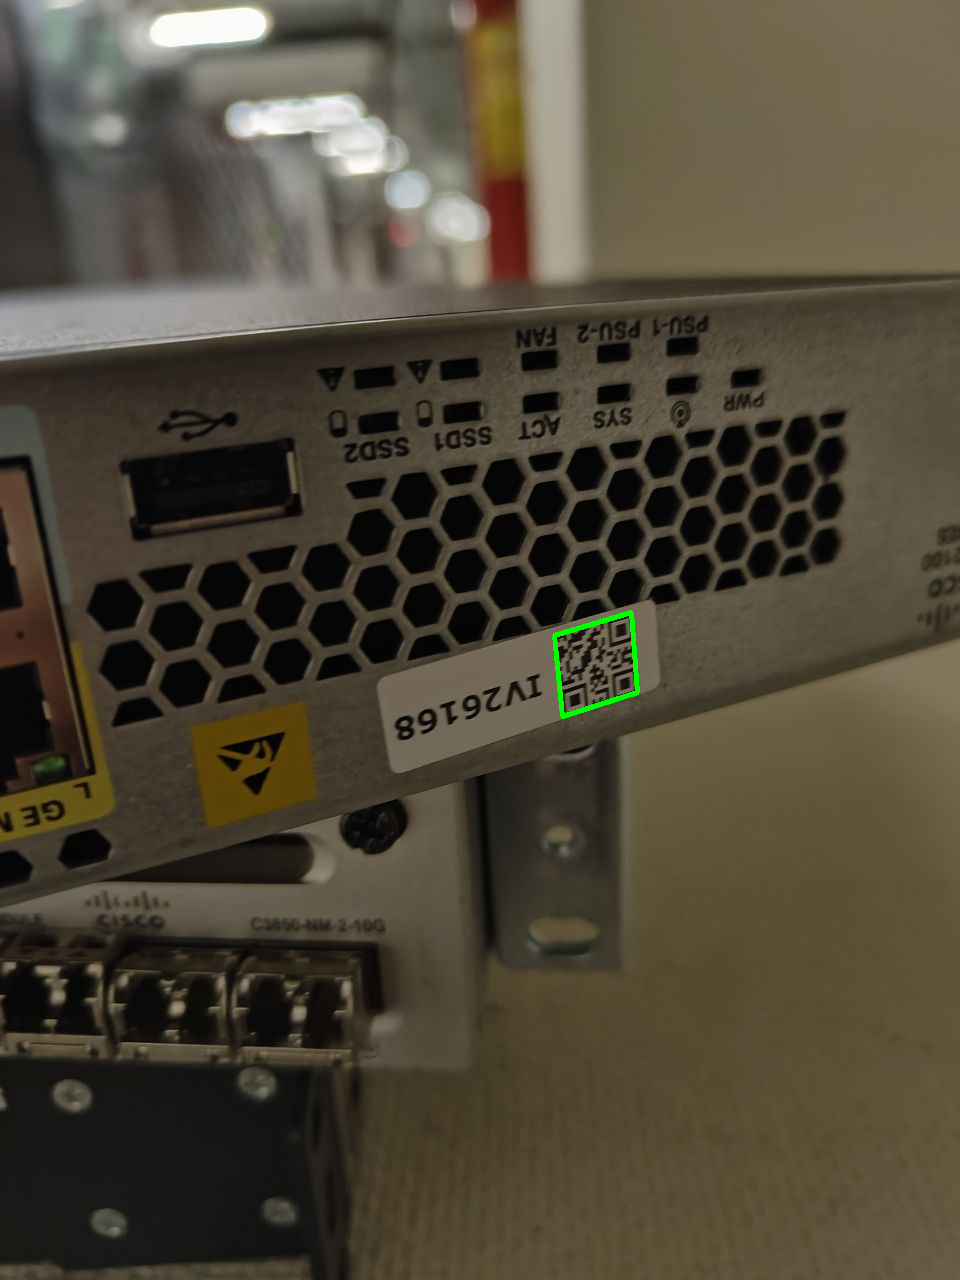

In [ ]:
from google.colab.patches import cv2_imshow
import numpy as np
import cv2


def order_quad_points(pts):
    pts = np.array(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).reshape(-1)

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]
    return np.array([tl, tr, br, bl], dtype=np.float32)


def warp_crop_by_quad(image, quad, out_size=None, border=10):
    quad = order_quad_points(quad)

    w1 = np.linalg.norm(quad[1] - quad[0])
    w2 = np.linalg.norm(quad[2] - quad[3])
    h1 = np.linalg.norm(quad[3] - quad[0])
    h2 = np.linalg.norm(quad[2] - quad[1])
    W = int(max(w1, w2)) + 2*border
    H = int(max(h1, h2)) + 2*border

    if out_size is not None:
        W, H = out_size

    dst = np.array([
        [border, border],
        [W-1-border, border],
        [W-1-border, H-1-border],
        [border, H-1-border]
    ], dtype=np.float32)

    M = cv2.getPerspectiveTransform(quad, dst)
    warped = cv2.warpPerspective(image, M, (W, H), flags=cv2.INTER_CUBIC)
    return warped


def detect_decode_and_crop(path, try_decode_on_crop=True):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)

    detector = cv2.QRCodeDetector()

    data, points, straight = detector.detectAndDecode(img)
    vis = img.copy()

    print("Decoded (full image):", repr(data))
    if points is None:
        print("QR not detected.")
        return img, None, None, None

    quad = points.reshape(-1, 2)
    quad_i = quad.astype(int)

    cv2.polylines(vis, [quad_i], isClosed=True, color=(0, 255, 0), thickness=3)
    if data:
        cv2.putText(vis, data[:60], (quad_i[0][0], quad_i[0][1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2, cv2.LINE_AA)

    cropped = warp_crop_by_quad(img, quad, border=15)

    data2 = None
    if try_decode_on_crop:
        data2, pts2, _ = detector.detectAndDecode(cropped)
        print("Decoded (cropped/warped):", repr(data2))

    return vis, cropped, data, data2


path = "test_angle.jpg"
vis, cropped, data_full, data_crop = detect_decode_and_crop(path)
cv2_imshow(vis)


Decoded (full image): ''
QR not detected.


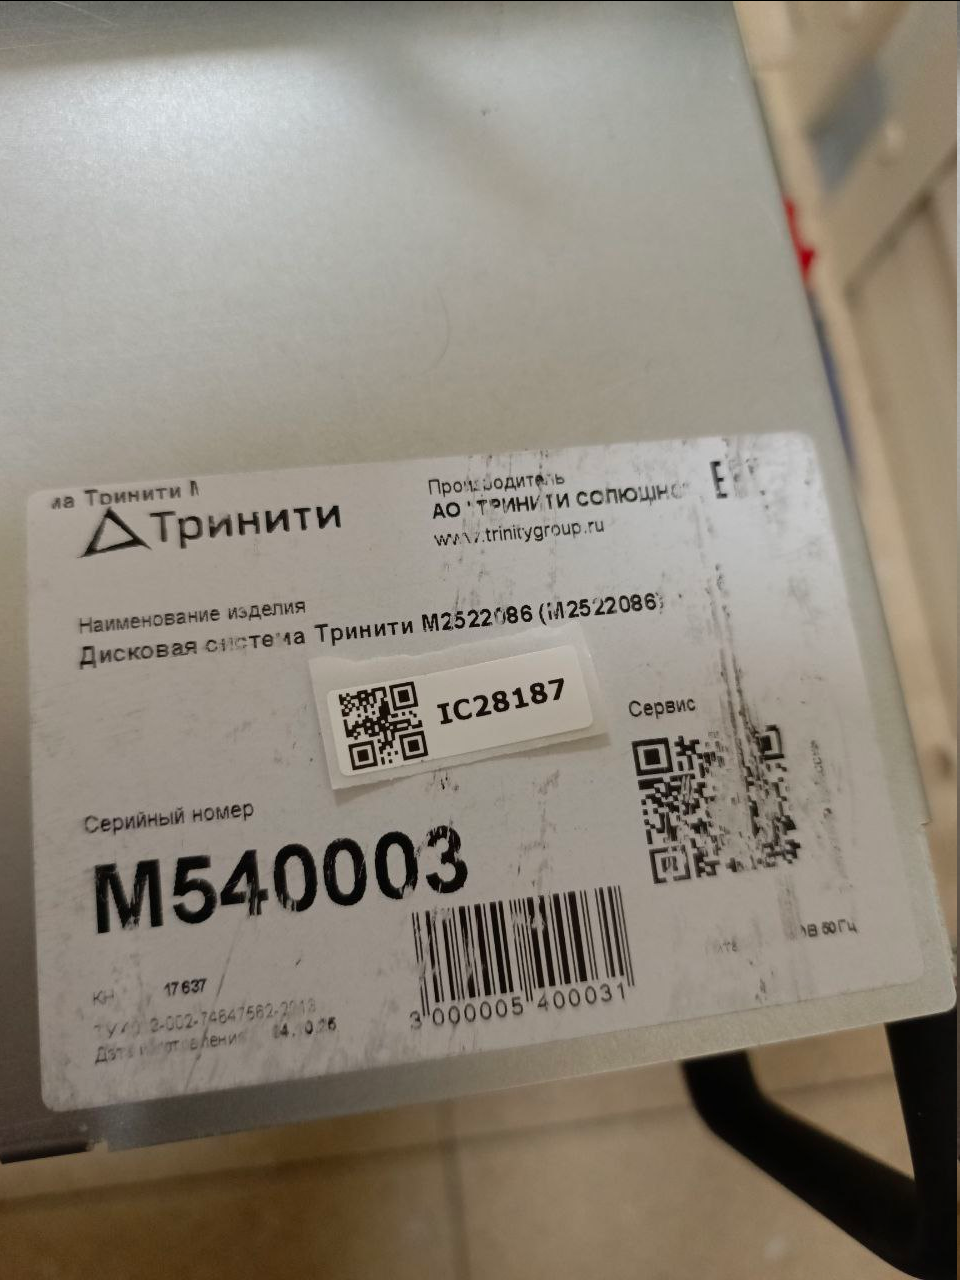

In [ ]:
path = "test01.png"
vis, cropped, data_full, data_crop = detect_decode_and_crop(path)
cv2_imshow(vis)


Decoded (full image): 'IC218'
Decoded (cropped/warped): 'IC218'


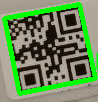

In [ ]:
path = "test01_cropped.png"
vis, cropped, data_full, data_crop = detect_decode_and_crop(path)
cv2_imshow(vis)
